In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

数据前5行：
   ID  State Code  County Code  Site Num                      Address  \
0   1           6           37      1103  1630 N MAIN ST, LOS ANGELES   
1   2           6           37      1103  1630 N MAIN ST, LOS ANGELES   
2   3           6           37      1103  1630 N MAIN ST, LOS ANGELES   
3   4           6           37      1103  1630 N MAIN ST, LOS ANGELES   
4   5           6           37      1103  1630 N MAIN ST, LOS ANGELES   

        State       County         City Date Local           O3 Units  \
0  California  Los Angeles  Los Angeles   2006/1/1  Parts per million   
1  California  Los Angeles  Los Angeles   2006/1/1  Parts per million   
2  California  Los Angeles  Los Angeles   2006/1/1  Parts per million   
3  California  Los Angeles  Los Angeles   2006/1/1  Parts per million   
4  California  Los Angeles  Los Angeles   2006/1/2  Parts per million   

    O3 Mean  O3 1st Max Value  O3 1st Max Hour  O3 AQI  
0  0.009625             0.017               16      14  
1

C:\Users\zhman\AppData\Local\Temp\ipykernel_19972\2209771254.py:69: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zhman\AppData\Local\Temp\ipykernel_19972\2209771254.py:69: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zhman\AppData\Local\Temp\ipykernel_19972\2209771254.py:69: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zhman\AppData\Local\Temp\ipykernel_19972\2209771254.py:69: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zhman\AppData\Local\Temp\ipykernel_19972\2209771254.py:69: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zhman\AppData\Local\Temp\ipykernel_19972\2209771254.py:69: UserWarning: Glyph 24180 (\

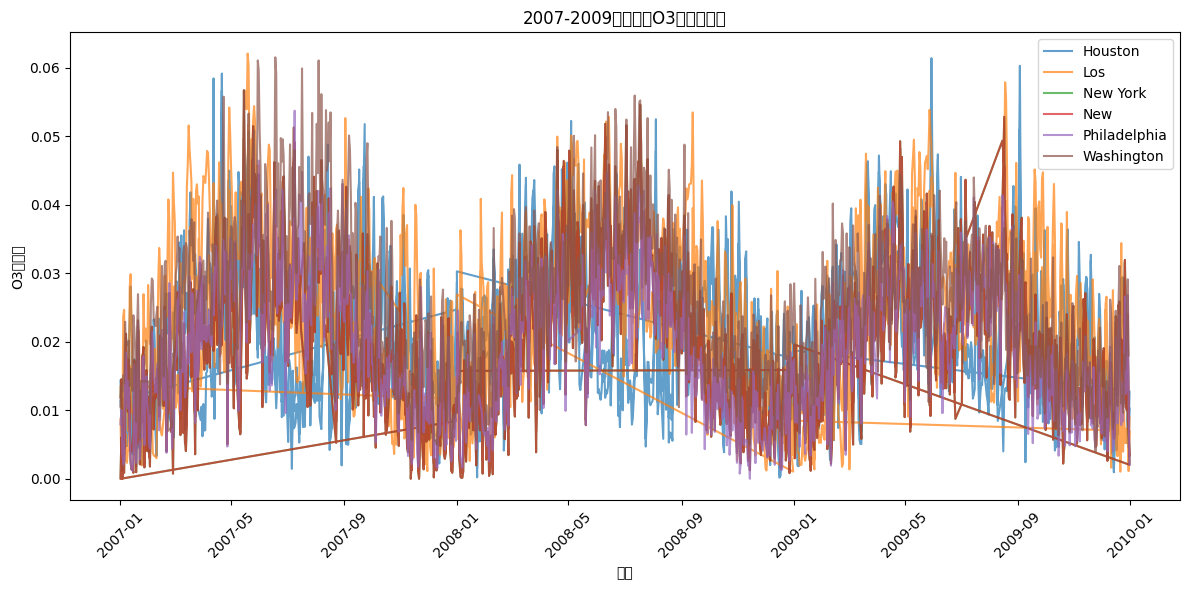

图表已保存


In [3]:
# 任务1：查看数据前5行和后2行
def task1():
    df = pd.read_csv('3.pollution_us_5city_2006_2010_O3.csv')
    print("数据前5行：")
    print(df.head())
    print("\n数据后2行：")
    print(df.tail(2))
    print("\n所有列名：")
    print(df.columns.tolist())
    print("\n所有城市：")
    print(df['City'].unique())

# 任务2：筛选2007-2009年数据并删除缺失值
def task2():
    df = pd.read_csv('3.pollution_us_5city_2006_2010_O3.csv')
    df_filtered = df[df['Date Local'].str.contains('2007|2008|2009')]
    df_filtered = df_filtered.dropna()
    df_filtered.to_csv('pollution_us_5city_2007_2009_O3.csv', index=False)
    print(f"筛选后数据：{len(df_filtered)}行")

# 任务3：按城市拆分数据并导出为文本文件
def task3():
    df = pd.read_csv('pollution_us_5city_2007_2009_O3.csv')
    cities = df['City'].unique()
    for city in cities:
        city_df = df[df['City'] == city]
        city_name = city.replace(' ', '_')  # 处理城市名中的空格
        city_df.to_csv(f'pollution_us_{city_name}_2007_2009_O3.txt',
                      sep=' ', index=False)
        print(f"导出{city}数据：{len(city_df)}行")

# 任务4：将文本文件转换为Excel
def task4():
    import os
    txt_files = [f for f in os.listdir() if f.endswith('.txt') and 'pollution_us' in f]
    for txt_file in txt_files:
        df = pd.read_csv(txt_file, sep=' ')
        excel_file = txt_file.replace('.txt', '.xlsx')
        df.to_excel(excel_file, index=False)
        print(f"转换{txt_file}为{excel_file}")

# 任务5：绘制对比图（以O3 Mean为例）
def task5():
    import os
    # 获取所有城市的Excel文件
    excel_files = [f for f in os.listdir() if f.endswith('.xlsx') and 'pollution_us' in f]

    # 读取数据
    city_dfs = []
    city_names = []
    for file in excel_files:
        city_name = file.split('_')[2]  # 从文件名提取城市名
        df = pd.read_excel(file)
        df['Date Local'] = pd.to_datetime(df['Date Local'])
        city_dfs.append(df)
        city_names.append(city_name)

    # 绘制O3 Mean对比图
    plt.figure(figsize=(12, 6))
    for df, city in zip(city_dfs, city_names):
        plt.plot(df['Date Local'], df['O3 Mean'], label=city, alpha=0.7)

    plt.xlabel('日期')
    plt.ylabel('O3平均值')
    plt.title('2007-2009年各城市O3平均值对比')
    plt.xticks(rotation=45)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.legend()
    plt.tight_layout()
    plt.savefig('各城市O3平均值对比.png')
    # plt.close()
    plt.show()
    print("图表已保存")

# 按顺序执行所有任务
if __name__ == "__main__":
    task1()
    task2()
    task3()
    task4()
    task5()